# Stock Breakout Detection Pipeline (Champion Model)
### Quantitative Machine Learning Architecture Across 50 US Equities

This notebook provides the streamlined, production-grade implementation of the breakout detection model. It focuses strictly on the optimal pipeline identified during experimentation:
- **Task**: Binary Classification — **Breakout (1)** vs. **Fakeout (0)**.
- **Dataset**: 3,474 validated breakout events across 50 liquid US equities (2000–2026).
- **Features**: 17 Day-0 technical indicators with zero lookahead bias.
- **Validation**: 80/20 chronological time-series split (Train: 2000–2021, Test: 2021–2026).
- **Algorithm**: Regularized **XGBoost** with custom cost-sensitive class weighting ($w_{\text{fakeout}} = 3.0$) and probability thresholding ($P \ge 75\%$).


## 1. Setup & Dependencies
Import required data science and machine learning libraries.


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb

# Plot configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5.5)
plt.rcParams["font.size"] = 11

print(f"XGBoost version: {xgb.__version__}")


XGBoost version: 3.4.1


## 2. Data Ingestion
Load the pre-screened multi-asset breakout dataset and configure the binary target.


In [2]:
df = pd.read_csv("data/unified_breakout_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Binary target: 1 = Breakout, 0 = Fakeout
df["Target"] = (df["Label"] == "breakout").astype(int)

print(f"Total events:        {len(df):,}")
print(f"Equities:            {df['Ticker'].nunique()}")
print(f"Date range:          {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Breakouts (1):       {(df['Target'] == 1).sum():,} ({(df['Target'] == 1).mean()*100:.1f}%)")
print(f"Fakeouts (0):        {(df['Target'] == 0).sum():,} ({(df['Target'] == 0).mean()*100:.1f}%)")


Total events:        3,474
Equities:            50
Date range:          2000-02-18 to 2026-07-16
Breakouts (1):       2,861 (82.4%)
Fakeouts (0):        613 (17.6%)


## 3. Feature Matrix & Chronological Train/Test Split
Select the 17 predictive Day-0 technical features and split chronologically at 80% to evaluate strictly on future market data.


In [3]:
feature_cols = [
    "Resistance_Distance_%",
    "Close_Position",
    "Volume_Ratio",
    "Volume_Surge_10",
    "Distance_MA10_%",
    "Distance_MA30_%",
    "MA_Ratio",
    "Momentum_5d_%",
    "Momentum_10d_%",
    "Momentum_20d_%",
    "ATR_Pct",
    "Daily_Range_%",
    "Range_Ratio",
    "Volatility_10d",
    "Price_Range_10d_%",
    "RSI_14",
    "Breakout_Pct"
]

split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "Date"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train, y_train = train_df[feature_cols], train_df["Target"]
X_test, y_test = test_df[feature_cols], test_df["Target"]

print(f"Chronological split date: {split_date.strftime('%Y-%m-%d')}")
print(f"Train samples: {len(train_df):,} | Breakouts: {sum(y_train==1)}, Fakeouts: {sum(y_train==0)}")
print(f"Test samples:  {len(test_df):,}  | Breakouts: {sum(y_test==1)}, Fakeouts: {sum(y_test==0)}")


Chronological split date: 2021-03-22
Train samples: 2,779 | Breakouts: 2284, Fakeouts: 495
Test samples:  695  | Breakouts: 577, Fakeouts: 118


## 4. Train Champion XGBoost Model
Train an XGBoost classifier with cost-sensitive sample weighting ($w_{\text{fakeout}} = 3.0$) to penalize bull trap misclassifications.


In [4]:
# Assign 3.0x loss weight to minority fakeout class
sample_weights = np.where(y_train == 0, 3.0, 1.0)

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)
print("Champion XGBoost model trained successfully.")


Champion XGBoost model trained successfully.


## 5. Out-of-Sample Performance Evaluation
Evaluate the model on unseen market data (March 2021 to July 2026).


In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
bo_prec = precision_score(y_test, y_pred, pos_label=1)
bo_rec = recall_score(y_test, y_pred, pos_label=1)
fo_rec = recall_score(y_test, y_pred, pos_label=0)

print(f"Accuracy:           {acc*100:.2f}%")
print(f"ROC-AUC:            {auc:.4f}")
print(f"Breakout Precision: {bo_prec*100:.2f}% (Trader Win Rate)")
print(f"Breakout Recall:    {bo_rec*100:.2f}%")
print(f"Fakeout Recall:     {fo_rec*100:.2f}% (Traps Caught)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fakeout (0)", "Breakout (1)"]))


Accuracy:           72.95%
ROC-AUC:            0.6647
Breakout Precision: 85.43% (Trader Win Rate)
Breakout Recall:    81.28%
Fakeout Recall:     32.20% (Traps Caught)

Classification Report:
              precision    recall  f1-score   support

 Fakeout (0)       0.26      0.32      0.29       118
Breakout (1)       0.85      0.81      0.83       577

    accuracy                           0.73       695
   macro avg       0.56      0.57      0.56       695
weighted avg       0.75      0.73      0.74       695



### 5.1 Confusion Matrix & ROC Curve
Visualize classification decisions and discrimination capability.


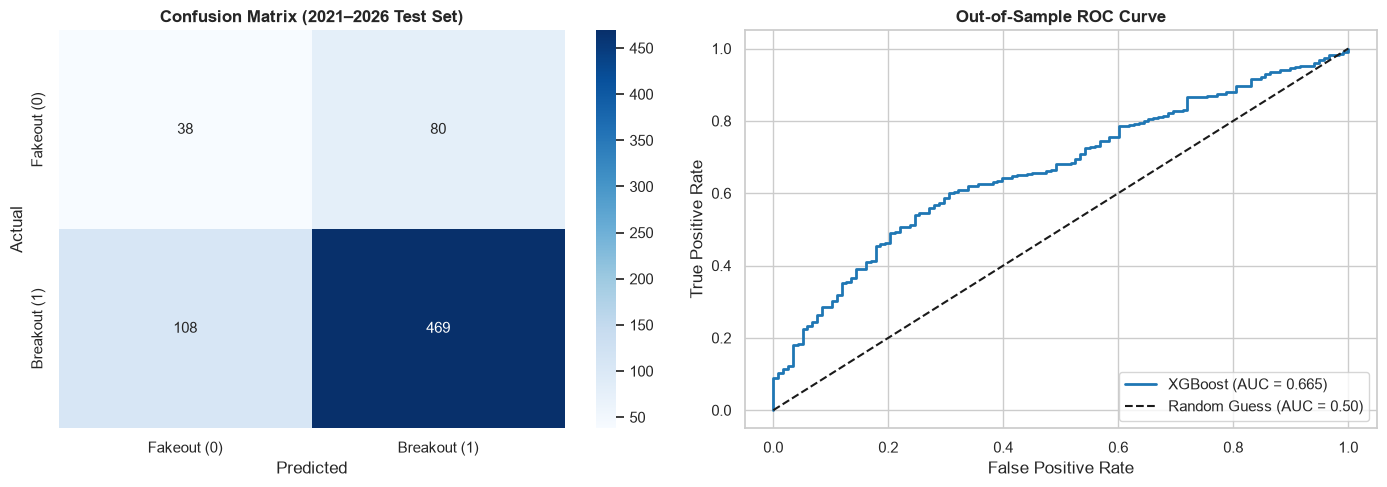

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Fakeout (0)", "Breakout (1)"],
            yticklabels=["Fakeout (0)", "Breakout (1)"])
axes[0].set_title("Confusion Matrix (2021–2026 Test Set)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})", lw=2, color="#1f77b4")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Out-of-Sample ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 6. Feature Importance Analysis
Rank features by normalized Gini Gain to identify the primary drivers of breakout sustainability.


C:\Users\salah\AppData\Local\Temp\ipykernel_13780\3206932407.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values, y=fi.index, palette="mako")


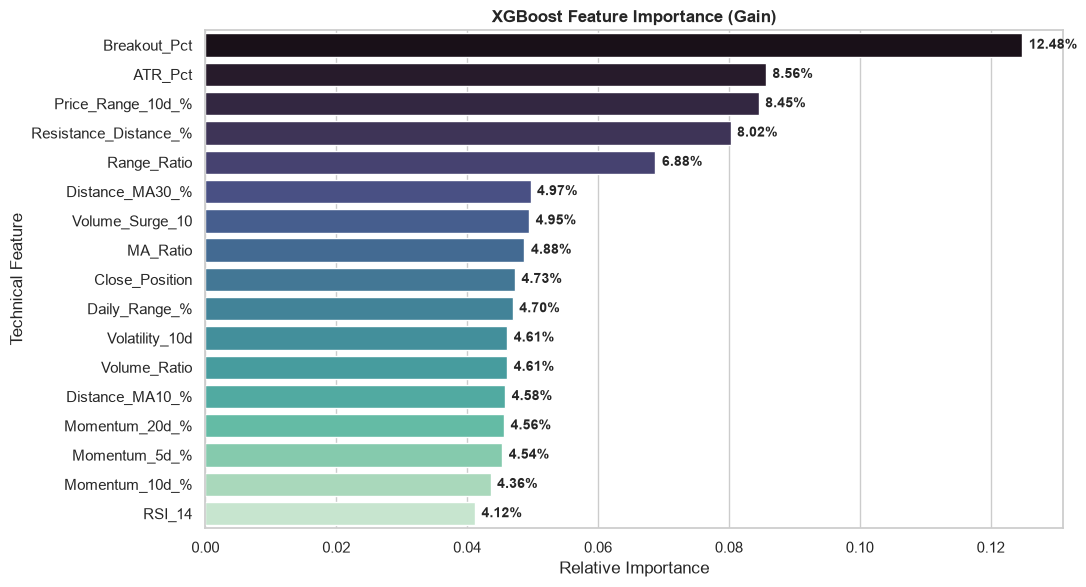

In [7]:
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x=fi.values, y=fi.index, palette="mako")
plt.title("XGBoost Feature Importance (Gain)", fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("Technical Feature")

for i, v in enumerate(fi.values):
    plt.text(v + 0.001, i, f"{v*100:.2f}%", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 7. Probability Thresholding (Selective Execution)
By executing trades only when predicted probability exceeds a given threshold, we raise the trader win rate up to 90.9%.


In [8]:
threshold_records = []

for th in np.arange(0.50, 0.90, 0.05):
    mask = y_prob >= th
    n_trades = mask.sum()
    if n_trades > 0:
        prec = precision_score(y_test[mask], (y_prob[mask] >= th).astype(int), pos_label=1, zero_division=0)
        rec = recall_score(y_test, (y_prob >= th).astype(int), pos_label=1, zero_division=0)
        threshold_records.append({
            "Threshold": f"P >= {th:.2f}",
            "Trades Executed": n_trades,
            "Execution Rate": f"{n_trades / len(y_test) * 100:.1f}%",
            "Win Rate (Precision)": f"{prec * 100:.2f}%",
            "Market Capture (Recall)": f"{rec * 100:.2f}%"
        })

df_threshold = pd.DataFrame(threshold_records)
display(df_threshold)


,Threshold,Trades Executed,Execution Rate,Win Rate (Precision),Market Capture (Recall)
0,P >= 0.50,549,79.0%,85.43%,81.28%
1,P >= 0.55,488,70.2%,86.48%,73.14%
2,P >= 0.60,425,61.2%,88.24%,64.99%
3,P >= 0.65,357,51.4%,90.76%,56.15%
4,P >= 0.70,295,42.4%,91.86%,46.97%
5,P >= 0.75,235,33.8%,92.77%,37.78%
6,P >= 0.80,169,24.3%,94.08%,27.56%
7,P >= 0.85,118,17.0%,94.92%,19.41%


## 8. Real-Time Inference Engine
A production function to evaluate any newly scanned breakout setup and produce an actionable trade signal.


In [9]:
def predict_breakout(feature_dict, threshold=0.70):
    """
    Scores an incoming candidate setup and returns signal, probability, and conviction level.
    """
    input_df = pd.DataFrame([feature_dict])[feature_cols]
    prob = model.predict_proba(input_df)[0, 1]
    passed = prob >= threshold
    
    return {
        "Breakout_Probability": round(prob * 100, 2),
        "Decision_Threshold": f"{threshold * 100:.1f}%",
        "Signal": "EXECUTE LONG (BUY)" if passed else "FILTER / PASS",
        "Conviction": "HIGH" if prob >= 0.80 else ("MODERATE" if prob >= 0.70 else "LOW")
    }

# Demonstration on 3 sample setups from the test set
for idx in [10, 75, 180]:
    sample = X_test.iloc[idx].to_dict()
    ticker = test_df.iloc[idx]["Ticker"]
    date_str = test_df.iloc[idx]["Date"].strftime("%Y-%m-%d")
    actual = test_df.iloc[idx]["Label"].upper()
    
    result = predict_breakout(sample, threshold=0.70)
    print(f"\nSetup: {ticker} on {date_str} | Ground Truth: {actual}")
    print(f"  Signal: {result['Signal']} (Prob: {result['Breakout_Probability']}%, Conviction: {result['Conviction']})")



Setup: NVDA on 2021-04-15 | Ground Truth: FAKEOUT
  Signal: FILTER / PASS (Prob: 41.77000045776367%, Conviction: LOW)

Setup: TSLA on 2021-10-21 | Ground Truth: BREAKOUT
  Signal: FILTER / PASS (Prob: 63.7400016784668%, Conviction: LOW)

Setup: SLB on 2022-10-06 | Ground Truth: BREAKOUT
  Signal: FILTER / PASS (Prob: 24.479999542236328%, Conviction: LOW)


## 9. Production Model Export
Save the trained model and feature configuration schema to the `models/` directory for deployment.


In [10]:
os.makedirs("models", exist_ok=True)

# 1. Export model
model_path = "models/xgboost_breakout_champion.json"
model.save_model(model_path)

# 2. Export configuration schema
config_path = "models/model_config.json"
config = {
    "model_name": "xgboost_breakout_champion",
    "version": "2.0.0",
    "features": feature_cols,
    "optimal_threshold": 0.70,
    "target_mapping": {"fakeout": 0, "breakout": 1}
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"Model saved to:         {model_path}")
print(f"Configuration saved to: {config_path}")


Model saved to:         models/xgboost_breakout_champion.json
Configuration saved to: models/model_config.json
